In [2]:
import random
import test_exercise_2 as test
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
# Aufgabe 1a
class Die:
    def __init__(self):
        self.value = random.randint(1, 6)

    def roll(self):
        self.value = random.randint(1, 6)

    def __repr__(self):
        return f"[{self.value}]"

In [4]:
test.test_task_2_1_a(Die)

✔ Your class 'Die' and its method 'roll' look good.


In [5]:
# Aufgabe 1b
def random_roll_method(die_class) -> bool:
    dice = [die_class() for _ in range(100)]
    
    # Zufällige Target-Summe wählen
    target_sum = random.randint(100, 600)
    
    start_time = time.time()
    max_duration = 180
    
    # Würfeln bis die Summe erreicht ist oder die Zeit abläuft
    while True:
        current_sum = sum(d.value for d in dice)
        
        if current_sum == target_sum:
            return True
        
        # Abbruchbedingung Zeit
        if (time.time() - start_time) > max_duration:
            return False
        
        # Alle Würfel neu würfeln
        for d in dice:
            d.roll()

In [7]:
import random
import test_exercise_2 as test
import time
test.test_task_2_1_b(random_roll_method, {"die_class": Die}, timeout=180)


⚠ Your random_roll_method took too long (> 180 seconds) and was terminated or an exception occured.


In [104]:
# Aufgabe 1c
class Individual:
    def __init__(self):
        self.dice = [Die() for _ in range(100)]
        
        # Speichert den Fitnesswert und initialen Fitnesswert direkt berechnen
        self.fitness = 0.0
        self.update_fitness()

    def update_fitness(self):
        # Je mehr Sechser, desto höher die Fitness (max. Fitness ist 100)
        self.fitness = sum(1 for die in self.dice if die.value == 6)
        return self.fitness

    def mutate(self, p: float):
        # Geht jeden Würfel durch und würfelt ihn mit der Wahrscheinlichkeit p neu.
        for die in self.dice:
            if random.random() < p:
                die.roll()

        self.update_fitness()

    def __repr__(self):
        return f"Individual(Fitness: {self.fitness})"

In [105]:
# Aufgabe 1d
POPULATION_SIZE = 100
SURVIVAL_RATE = 0.25
MUTATION_RATE = 0.07
MAX_GENERATIONS = 1000
TARGET_FITNESS = 100

In [106]:
# Aufgabe 1e
def run_evolution(pop_size=POPULATION_SIZE, mutation_rate=MUTATION_RATE,
                  max_gen=MAX_GENERATIONS, survival_rate=SURVIVAL_RATE):
    # Initialisierung
    population = [Individual() for _ in range(pop_size)]
    num_survivors = int(pop_size * survival_rate)

    for iteration in range(max_gen):
        # Fitness absteigend sortieren
        population.sort(key=lambda ind: ind.fitness, reverse=True)

        # Haben wir hundert Sechser?
        if population[0].fitness == 100:
            break

        # Selektion
        survivors = population[:num_survivors]

        # Reproduktion
        next_gen = list(survivors)
        while len(next_gen) < POPULATION_SIZE:
            # Zwei zufällige Eltern aus den Überlebenden auswählen
            parent1 = random.choice(survivors)
            parent2 = random.choice(survivors)

            # Neues Kind erstellen
            child = Individual()

            for i in range(100):
                # Mit 50% Wahrscheinlichkeit Gen von Parent 1, sonst von Parent 2
                if random.random() < 0.5:
                    child.dice[i].value = parent1.dice[i].value
                else:
                    child.dice[i].value = parent2.dice[i].value

            child.mutate(MUTATION_RATE)

            # Kind der neuen Generation hinzufügen
            next_gen.append(child)

        # Die alte Population durch die neue Gen ersetzen
        population = next_gen

    best_ind = population[0]
    return [die.value for die in best_ind.dice]

In [107]:
params = {
        "pop_size": POPULATION_SIZE,
        "mutation_rate": MUTATION_RATE,
        "max_gen": MAX_GENERATIONS,
        "survival_rate": SURVIVAL_RATE
    }

test.test_task_2_1_e(run_evolution, params)

✔ Your evolutionary algorithm rolls all dice to show 6: [6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]
ℹ Your evolutionary algorithm took 4.41 seconds to run.


4.40976095199585

In [108]:
"""
Aufgabe 1f:
Anstelle davon, dass die ganzen Die- und Individual-Objekte durchgegangen werden,
erstelle ich eine Matrix mit numpy, die die Struktur repräsentiert, wobei
(Zeilen = Individuen, Spalten = Würfel).
Des Weiteren benutze ich np.sum um die Fitness schneller auszurechnen.
Ich benutze auch np.argsort zum sortieren.
"""

'\nAufgabe 1f:\nAnstelle davon, dass die ganzen Die- und Individual-Objekte durchgegangen werden,\nerstelle ich eine Matrix mit numpy, die die Struktur repräsentiert, wobei\n(Zeilen = Individuen, Spalten = Würfel).\nDes Weiteren benutze ich np.sum um die Fitness schneller auszurechnen.\nIch benutze auch np.argsort zum sortieren.\n'

In [109]:
def run_evolution_optimized(pop_size=POPULATION_SIZE, mutation_rate=MUTATION_RATE,
                            max_gen=MAX_GENERATIONS, survival_rate=SURVIVAL_RATE):
    num_dice = 100
    num_survivors = int(pop_size * survival_rate)

    # Initialisierung
    population = np.random.randint(1, 7, size=(pop_size, num_dice))

    for _ in range(max_gen):
        # Fitness berechnen (Anzahl der Sechsen pro Zeile)
        fitness = np.sum(population == 6, axis=1)

        # Sortieren (Indizes der besten Individuen finden)
        sorted_indices = np.argsort(fitness)[::-1]
        best_fitness = fitness[sorted_indices[0]]

        if best_fitness == num_dice:
            return population[sorted_indices[0]]

        # Selektion
        survivors = population[sorted_indices[:num_survivors]]

        # Auffüllen der Population
        new_population = np.zeros_like(population)
        new_population[:num_survivors] = survivors

        # Reproduktion
        for i in range(num_survivors, pop_size):
            # Zwei zufällige Eltern aus den Überlebenden wählen
            parent1 = survivors[random.randint(0, num_survivors - 1)]
            parent2 = survivors[random.randint(0, num_survivors - 1)]

            # Ein neues Kind erstellen
            child = np.zeros(num_dice, dtype=int)

            # Crossover
            for g in range(num_dice):
                if random.random() < 0.5:
                    child[g] = parent1[g]
                else:
                    child[g] = parent2[g]

            # Mutation
            for g in range(num_dice):
                if random.random() < mutation_rate:
                    child[g] = random.randint(1, 6)

            new_population[i] = child
        population = new_population

    final_fitness = np.sum(population == 6, axis=1)
    return population[np.argmax(final_fitness)]

In [110]:
params_def = {
    "pop_size": POPULATION_SIZE,
    "mutation_rate": MUTATION_RATE,
    "max_gen": MAX_GENERATIONS,
    "survival_rate": SURVIVAL_RATE
}

params_opt = {
    "pop_size": POPULATION_SIZE,
    "mutation_rate": MUTATION_RATE,
    "max_gen": MAX_GENERATIONS,
    "survival_rate": SURVIVAL_RATE
}

test.test_task_2_1_f(
    run_evolution,
    params_def,
    run_evolution_optimized,
    params_opt
    )


ℹ Testing the default evolutionary algorithm...
✔ Your evolutionary algorithm rolls all dice to show 6: [6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]
ℹ Your evolutionary algorithm took 3.78 seconds to run.

ℹ Testing the optimized evolutionary algorithm...
✔ Your evolutionary algorithm rolls all dice to show 6: [6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]
ℹ Your evolutionary algorithm took 0.92 seconds to run.

✔ Your optimized evolutionary algorithm was 4.12 times faster than your default evolutionary algorithm.


4.117161426176226

In [111]:
# Aufgabe 2

In [112]:
# Aufgabe 2a
def generate_random_graph(n_nodes: int, n_edges: int) -> nx.Graph:
    graph = nx.gnm_random_graph(n_nodes, n_edges)
    return graph

In [113]:
test.test_task_2_2_a(generate_random_graph,20, 20)

✔ Your function generates a graph with 20 nodes and 20 edges.


In [114]:
# Aufgabe 2b
def calculate_fitness(individual, graph):
    # welche Knoten sind im Bitstring auf 1 gesetzt
    auswahl = []
    for i in range(len(individual)):
        if individual[i] == 1:
            auswahl.append(i)
    
    # Falls gar kein Knoten gewählt wurde
    if len(auswahl) == 0:
        return 0

    anzahl = len(auswahl)
    
    # Teilgraph erstellen, um die Kanten zu prüfen
    sub = graph.subgraph(auswahl)
    kanten_da = sub.number_of_edges()
    
    # Formel für die Kanten einer vollständigen Clique: n*(n-1)/2
    kanten_max = (anzahl * (anzahl - 1)) / 2
    
    fehlende_kanten = kanten_max - kanten_da

    if fehlende_kanten == 0:
        # ist eine Clique
        return anzahl
    else:
        # Bestrafung, falls es keine Clique ist
        fitness = anzahl - fehlende_kanten - 1
        
        # Sicherstellen dass Fitness nicht negativ wird
        if fitness < 0:
            return 0
        return fitness

In [115]:
def evolutionary_clique_algorithm(graph, pop_size=100, mutation_rate=0.02, max_iter=200, survival_rate=0.2):
    nodes = list(graph.nodes)
    num_nodes = len(nodes)

    # Population erstellen: Eine Liste von Listen mit 0 und 1
    population = []
    for _ in range(pop_size):
        ind = [random.randint(0, 1) for _ in range(num_nodes)]
        population.append(ind)

    def get_fitness(individual):
        # Welche Knoten wurden ausgewählt?
        selected_nodes = []
        for i in range(num_nodes):
            if individual[i] == 1:
                selected_nodes.append(nodes[i])

        if not selected_nodes:
            return 0

        # Teilgraph bauen, um Kanten zu zählen
        sub_graph = graph.subgraph(selected_nodes)
        n = len(selected_nodes)
        actual_edges = sub_graph.number_of_edges()

        # Maximale Kanten für eine Clique
        max_edges = (n * (n - 1)) / 2

        if actual_edges == max_edges:
            return n  # Es ist eine Clique, Fitness ist die Größe
        else:
            # Keine Clique
            missing = max_edges - actual_edges
            fitness = n - missing - 1
            return max(0, fitness)

    for iteration in range(max_iter):
        # Fitness für alle berechnen
        all_fitness = []
        for ind in population:
            all_fitness.append(get_fitness(ind))

        # Nach Fitness sortieren (Paare aus Fitness und Individuum bilden)
        combined = []
        for i in range(len(population)):
            entry = (all_fitness[i], population[i])
            combined.append(entry)
            
        combined.sort(key=lambda x: x[0], reverse=True)

        # Die besten auswählen
        num_survivors = int(pop_size * survival_rate)
        survivors = []
        for i in range(num_survivors):
            pair = combined[i]
            individual = pair[1]
            survivors.append(individual)

        new_gen = []
        new_gen.extend(survivors)

        # Den Rest der neuen Generation auffüllen
        while len(new_gen) < pop_size:
            # Zwei zufällige Eltern aus den Überlebenden wählen
            parent1 = random.choice(survivors)
            parent2 = random.choice(survivors)

            child = []
            for i in range(num_nodes):
                if random.random() < 0.5:
                    child.append(parent1[i])
                else:
                    child.append(parent2[i])

            # Mutation
            for i in range(num_nodes):
                if random.random() < mutation_rate:
                    if child[i] == 0:
                        child[i] = 1
                    else:
                        child[i] = 0

            new_gen.append(child)

        population = new_gen

    # Am Ende das beste Individuum raussuchen
    final_fitness = [get_fitness(ind) for ind in population]
    best_idx = final_fitness.index(max(final_fitness))
    best_ind = population[best_idx]

    result = []
    for i in range(num_nodes):
        if best_ind[i] == 1:
            result.append(nodes[i])

    return result

In [116]:
graph = generate_random_graph(10, 20)
cliques = list(nx.find_cliques(graph))
max_clique_size = max(len(c) for c in cliques)
print(f"Referenz: NetworkX hat maximale Clique der Größe {max_clique_size} gefunden.")

params_graph = {"graph": graph, "pop_size": 100, "max_iter": 300}

test.test_task_2_2_c(evolutionary_clique_algorithm, params_graph)

Referenz: NetworkX hat maximale Clique der Größe 3 gefunden.
✔ Your evolutionary algorithm found one of the maximum cliques: [0, 5, 9]
 all possible maximum cliques are: [[0, 2, 6], [0, 5, 8], [0, 5, 9], [0, 3, 5], [1, 4, 9], [4, 5, 8], [4, 5, 9], [3, 4, 5], [4, 5, 7]]
ℹ Your evolutionary algorithm took 1.34 seconds to run.


[0, 5, 9]

In [117]:
# Aufgabe 2d
def plot_graph_with_clique(graph, clique_nodes):
    pos = nx.spring_layout(graph)
    
    colors = []
    for node in graph.nodes():
        if node in clique_nodes:
            colors.append('red')
        else:
            colors.append('blue')
            
    plt.figure(figsize=(8, 6))
    nx.draw(graph, pos, with_labels=True, node_color=colors, node_size=500, edge_color='lightgray')
    plt.title(f"Gefundene Clique (Groesse: {len(clique_nodes)})")
    plt.show()

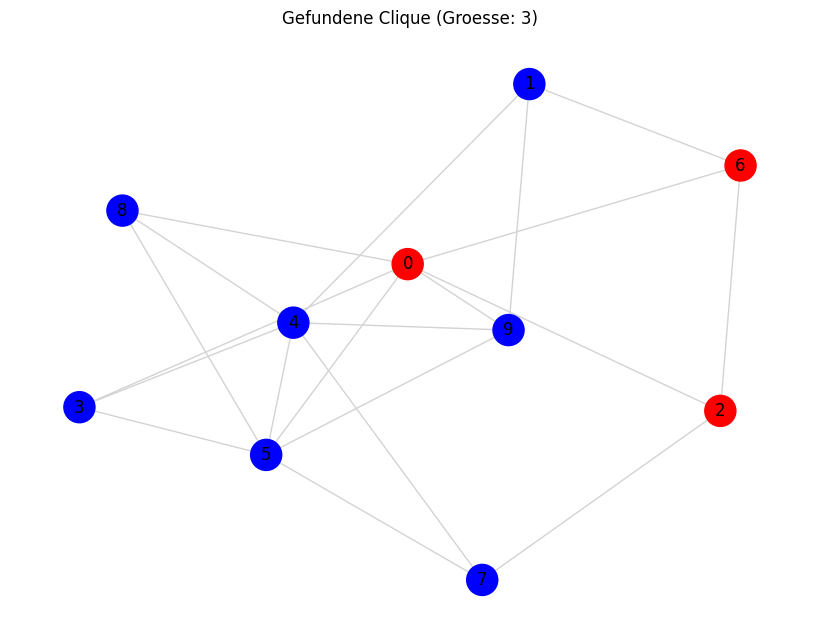

In [118]:
found_clique = evolutionary_clique_algorithm(graph)
plot_graph_with_clique(graph, found_clique)

In [120]:
# Aufgabe 2e
params = {
        "graph": None,
        "pop_size": 150,
        "mutation_rate": 0.05,
        "max_iter": 500,
        "survival_rate": 0.2
}
test.test_task_2_2_e(evolutionary_clique_algorithm, params)


ℹ Testing graph with 10 nodes and 20 edges...
✔ Your evolutionary algorithm found one of the maximum cliques: [4, 7, 8]
 all possible maximum cliques are: [[0, 1, 7], [1, 8, 9], [1, 7, 8], [1, 5, 9], [1, 2, 5], [3, 4, 7], [4, 6, 8], [4, 7, 8], [6, 8, 9], [5, 6, 9]]
ℹ Your evolutionary algorithm took 3.41 seconds to run.

ℹ Testing graph with 10 nodes and 40 edges...
✔ Your evolutionary algorithm found one of the maximum cliques: [0, 1, 2, 3, 5, 8]
 all possible maximum cliques are: [[0, 3, 5, 7, 8, 9], [0, 5, 6, 7, 8, 9], [0, 3, 4, 5, 7, 9], [0, 4, 5, 6, 7, 9], [0, 1, 2, 3, 5, 8], [0, 1, 2, 5, 6, 8], [0, 1, 2, 3, 4, 5], [0, 1, 2, 4, 5, 6], [0, 2, 3, 5, 7, 8], [0, 2, 5, 6, 7, 8], [0, 2, 3, 4, 5, 7], [0, 2, 4, 5, 6, 7]]
ℹ Your evolutionary algorithm took 5.45 seconds to run.

ℹ Testing graph with 20 nodes and 40 edges...
✔ Your evolutionary algorithm found one of the maximum cliques: [12, 14, 18]
 all possible maximum cliques are: [[1, 2, 16], [2, 3, 9], [2, 3, 17], [2, 9, 16], [1, 5, 1